## 1. Import Libraries

We import the core data manipulation, visualization, and machine learning libraries used throughout this project. `warnings` are suppressed for a clean, presentation-ready notebook, and a global random seed is set for full reproducibility.

In [101]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

We load the dataset and perform an initial inspection: shape, column names, sample rows, data types, and summary statistics.

In [102]:
df = pd.read_csv('Country-data.csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (167, 10)

Column names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [103]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.200,10.000,7.580,44.900,1610,9.440,56.200,5.820,553
1,Albania,16.600,28.000,6.550,48.600,9930,4.490,76.300,1.650,4090
2,Algeria,27.300,38.400,4.170,31.400,12900,16.100,76.500,2.890,4460
3,Angola,119.000,62.300,2.850,42.900,5900,22.400,60.100,6.160,3530
4,Antigua and Barbuda,10.300,45.500,6.030,58.900,19100,1.440,76.800,2.130,12200


In [104]:
df.tail()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
162,Vanuatu,29.200,46.600,5.250,52.700,2950,2.620,63.000,3.500,2970
163,Venezuela,17.100,28.500,4.910,17.600,16500,45.900,75.400,2.470,13500
164,Vietnam,23.300,72.000,6.840,80.200,4490,12.100,73.100,1.950,1310
165,Yemen,56.300,30.000,5.180,34.400,4480,23.600,67.500,4.670,1310
166,Zambia,83.100,37.000,5.890,30.900,3280,14.000,52.000,5.400,1460


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [106]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000
mean,38.270,41.109,6.816,46.890,17144.689,7.782,70.556,2.948,12964.156
std,40.329,27.412,2.747,24.210,19278.068,10.571,8.893,1.514,18328.705
min,2.600,0.109,1.810,0.066,609.000,-4.210,32.100,1.150,231.000
25%,8.250,23.800,4.920,30.200,3355.000,1.810,65.300,1.795,1330.000
50%,19.300,35.000,6.320,43.300,9960.000,5.390,73.100,2.410,4660.000
75%,62.100,51.350,8.600,58.750,22800.000,10.750,76.800,3.880,14050.000
max,208.000,200.000,17.900,174.000,125000.000,104.000,82.800,7.490,105000.000


**Interpretation:** The dataset contains **167 countries** described by **9 numeric macroeconomic/social indicators** plus the country name. There are no obvious structural issues from `info()` — all numeric columns are already typed as `float64`/`int64`. The `describe()` output shows very large spreads in `income` and `gdpp` (a few hundred to tens of thousands of dollars), which strongly hints that the data spans both very poor and very wealthy nations — this is the core signal our clustering models will exploit.

## 3. Data Cleaning

Even though this dataset is relatively clean, we apply a standard, defensive cleaning pipeline that any production-grade analytics system should run on incoming data:

1. Strip whitespace from column names
2. Remove duplicate rows
3. Coerce all indicator columns to numeric (any malformed values become `NaN`)
4. Impute any missing values using the **median** (robust to outliers/skew)
5. Report missing-value counts before and after cleaning

In [107]:
# 1. Strip whitespace from column names
df.columns = df.columns.str.strip()

# Missing values BEFORE cleaning
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# 2. Remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDuplicate rows removed: {duplicates_before}")

# 3. Convert all numeric columns using pd.to_numeric
numeric_cols = df.columns.drop('country')
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Median imputation for any resulting missing values
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Missing values AFTER cleaning
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

print("\nFinal shape:", df.shape)

Missing values BEFORE cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows removed: 0

Missing values AFTER cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final shape: (167, 10)


**Cleaning summary:** The dataset arrived with **zero missing values and zero duplicate rows**, so the cleaning pipeline made no changes to the data itself — however, running it is still considered best practice because it guarantees the pipeline is **robust to future data refreshes** that may contain dirty values (e.g. a new export of this dataset with stray text, extra whitespace, or blanks). All 9 indicator columns are confirmed as clean numeric data ready for analysis.

## 4. Exploratory Data Analysis (EDA)

In this section we visualize the distributions of key indicators, examine relationships between variables, and identify the countries at the extremes of economic development. Each chart is followed by a short business interpretation.

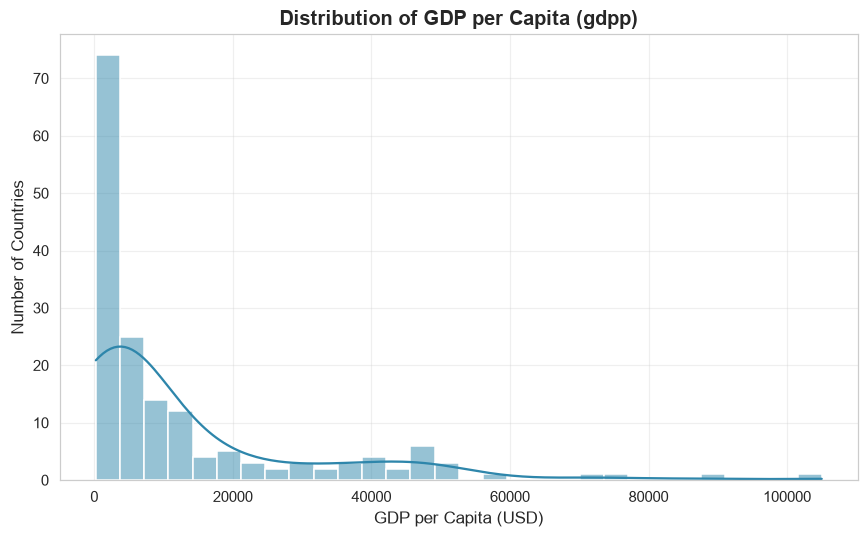

In [108]:
plt.figure(figsize=(8,5))
sns.histplot(df['gdpp'], bins=30, kde=True, color='#2E86AB')
plt.title('Distribution of GDP per Capita (gdpp)', fontsize=13, fontweight='bold')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Number of Countries')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** GDP per capita is heavily **right-skewed** — most countries cluster below \$20,000, while a small group of wealthy nations (e.g. Luxembourg at \$105,000, Norway at \$87,800) pull the tail far to the right. This skew is a strong motivation for **feature scaling** before clustering.

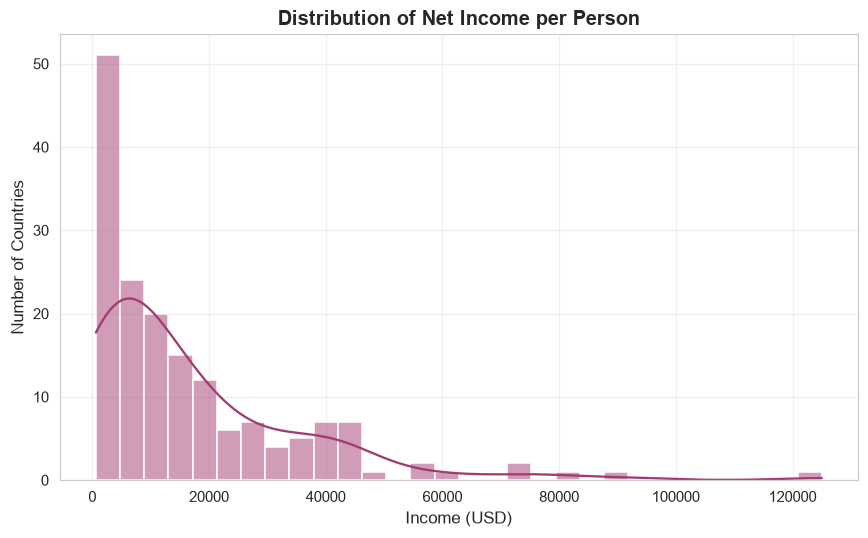

In [109]:
plt.figure(figsize=(8,5))
sns.histplot(df['income'], bins=30, kde=True, color='#A23B72')
plt.title('Distribution of Net Income per Person', fontsize=13, fontweight='bold')
plt.xlabel('Income (USD)')
plt.ylabel('Number of Countries')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Income follows a similar right-skewed pattern to GDP, with a long tail of oil-rich and highly developed economies (Qatar, Luxembourg, Brunei). The strong visual similarity between the income and GDP distributions foreshadows the **very high correlation (≈0.90)** we will confirm in the heatmap below.

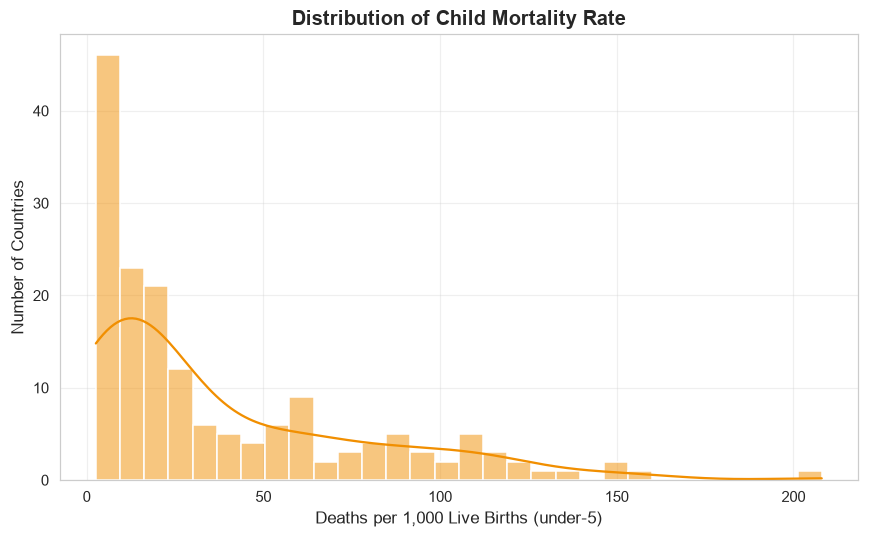

In [110]:
plt.figure(figsize=(8,5))
sns.histplot(df['child_mort'], bins=30, kde=True, color='#F18F01')
plt.title('Distribution of Child Mortality Rate', fontsize=13, fontweight='bold')
plt.xlabel('Deaths per 1,000 Live Births (under-5)')
plt.ylabel('Number of Countries')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Child mortality ranges from as low as **2.6** to as high as **208** deaths per 1,000 live births — an enormous gap. The median is around **19**, but a sizeable group of countries (mostly in Sub-Saharan Africa) sit well above 60, marking them as priority candidates for health-focused development aid.

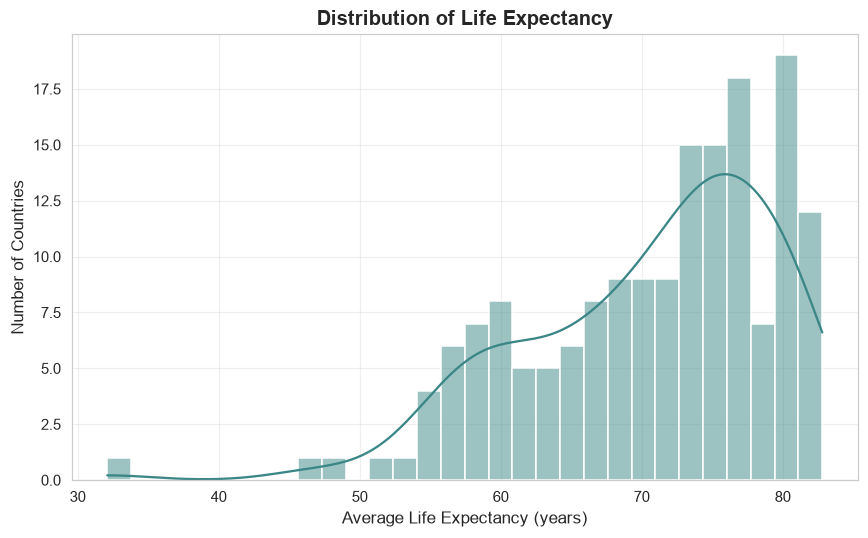

In [111]:
plt.figure(figsize=(8,5))
sns.histplot(df['life_expec'], bins=30, kde=True, color='#3B8686')
plt.title('Distribution of Life Expectancy', fontsize=13, fontweight='bold')
plt.xlabel('Average Life Expectancy (years)')
plt.ylabel('Number of Countries')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Life expectancy is left-skewed, with most countries between 70-80 years but a tail extending down to **32 years**. This mirrors the child mortality distribution (as expected — the two are strongly negatively correlated) and reinforces that health outcomes form a coherent "development axis" in the data.

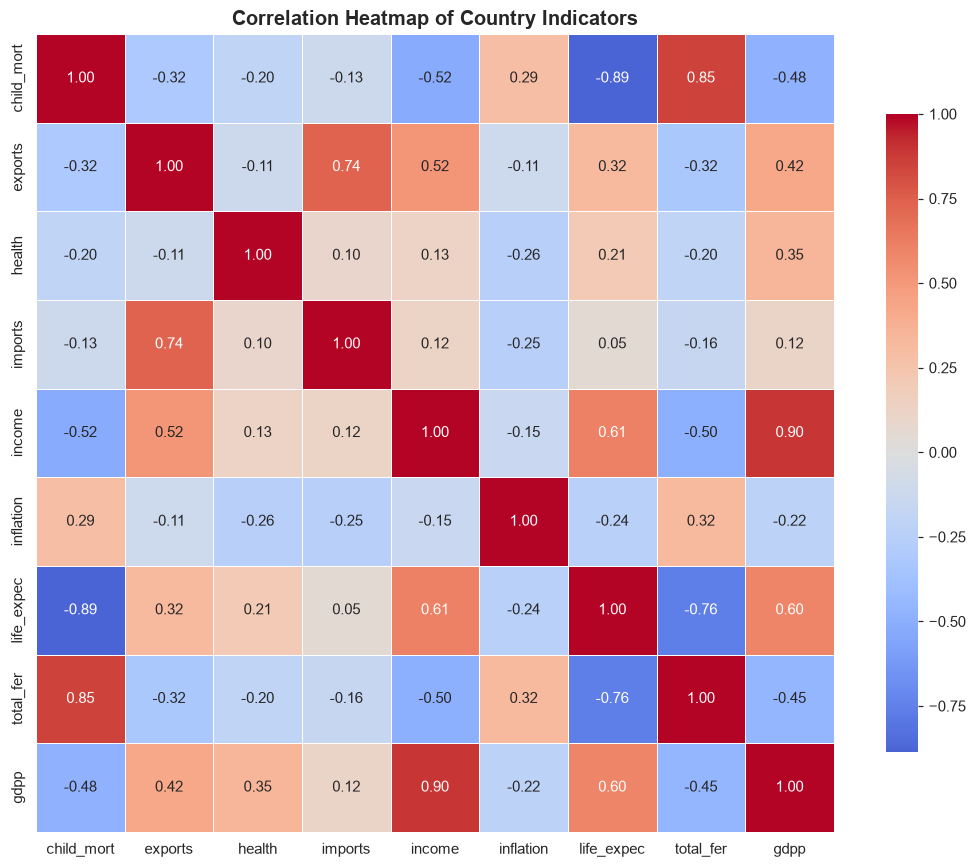

In [112]:
plt.figure(figsize=(10,8))
corr = df.drop(columns='country').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Country Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** `income` and `gdpp` are very strongly correlated (**r ≈ 0.90**), and both are negatively correlated with `child_mort` (**r ≈ -0.48 to -0.52**) and positively correlated with `life_expec` (**r ≈ 0.60-0.61**). This confirms a single dominant "development" axis running through the data — exactly the kind of structure K-Means and PCA are well suited to uncover. `total_fer` (fertility rate) is also strongly negatively correlated with `gdpp` and `life_expec`, consistent with the well-documented demographic transition.

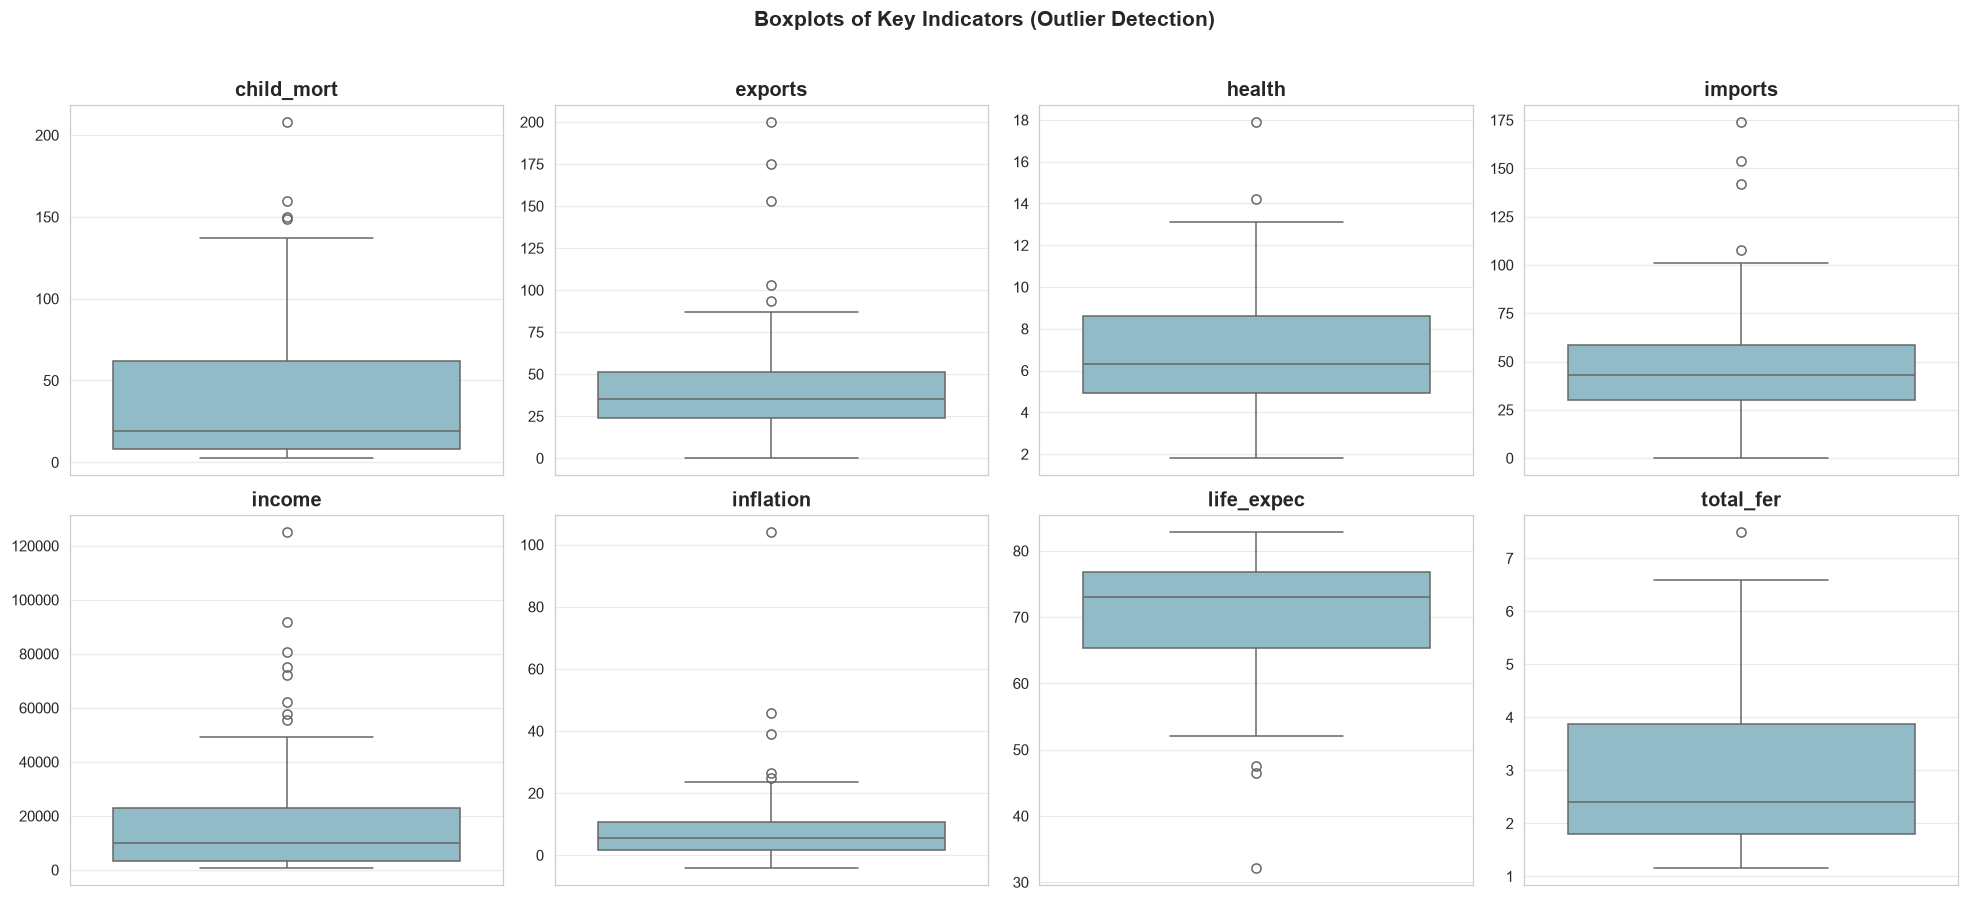

In [113]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
box_cols = ['child_mort','exports','health','imports','income','inflation','life_expec','total_fer']
for ax, col in zip(axes.flatten(), box_cols):
    sns.boxplot(y=df[col], ax=ax, color='#88C0D0')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('')
plt.suptitle('Boxplots of Key Indicators (Outlier Detection)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:** `income`, `inflation`, and `child_mort` show the most extreme outliers — a handful of oil-rich Gulf states drive the income outliers, while a few high-inflation and high-child-mortality nations (often post-conflict states) appear as separate points well above the upper whisker. These are not data errors; they represent **genuinely atypical economies** that DBSCAN should help us flag as noise/outlier points later in the analysis.

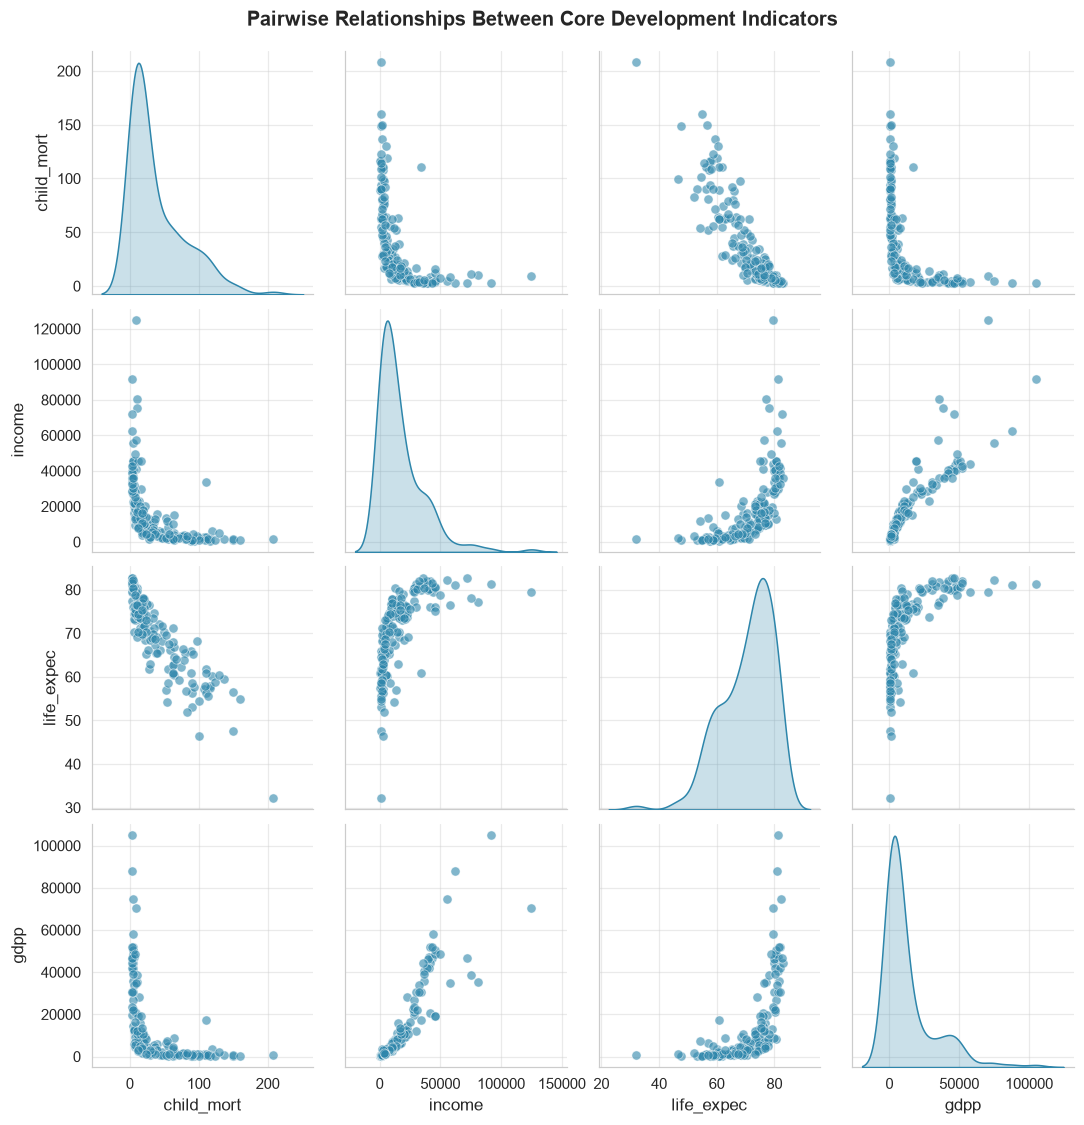

In [114]:
sns.pairplot(df[['child_mort','income','life_expec','gdpp']], diag_kind='kde',
             plot_kws={'alpha':0.6, 'color':'#2E86AB'}, diag_kws={'color':'#2E86AB'})
plt.suptitle('Pairwise Relationships Between Core Development Indicators', y=1.02, fontsize=13, fontweight='bold')
plt.show()

**Insight:** The pairplot makes the development axis visually explicit: countries with **high income and gdpp** cluster toward **low child mortality and high life expectancy**, forming a clear curved relationship (diminishing returns at high income levels) rather than a straight line — a useful nuance for interpreting cluster boundaries.

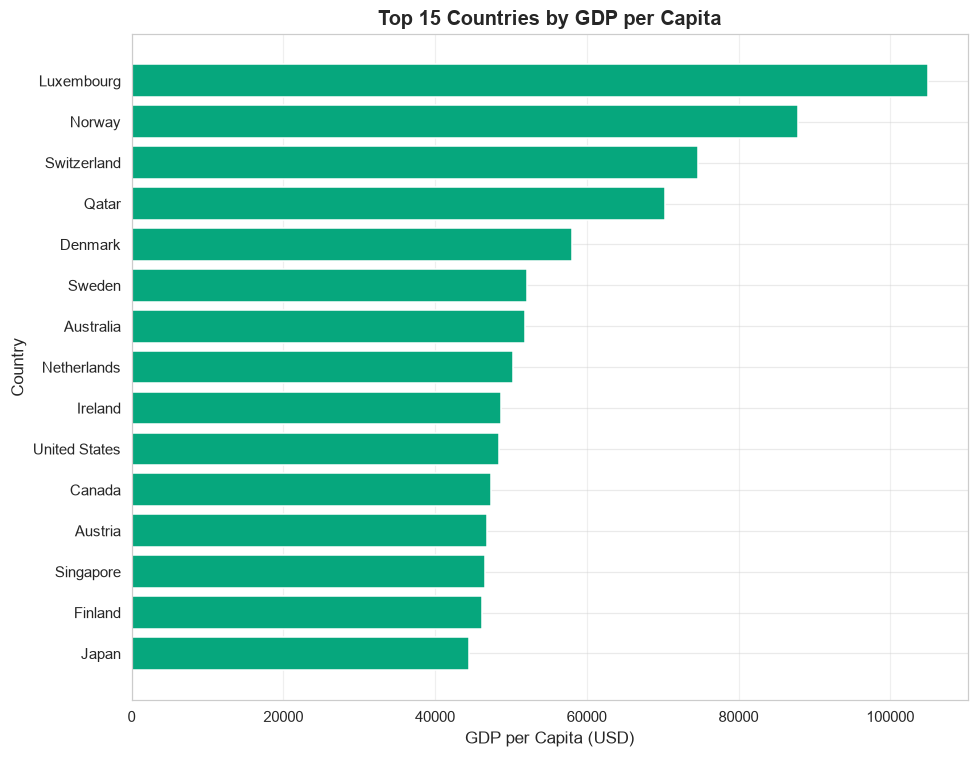

In [115]:
top15_gdp = df.nlargest(15, 'gdpp').sort_values('gdpp')
plt.figure(figsize=(9,7))
plt.barh(top15_gdp['country'], top15_gdp['gdpp'], color='#06A77D')
plt.title('Top 15 Countries by GDP per Capita', fontsize=13, fontweight='bold')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Country')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** **Luxembourg (\$105,000)**, **Norway (\$87,800)** and **Switzerland (\$74,600)** lead the dataset by a wide margin — all small, highly specialized, high-income economies. Notably, **Qatar** appears here too, reflecting an oil/gas-driven GDP rather than broad-based industrial development, a distinction we will revisit when profiling clusters.

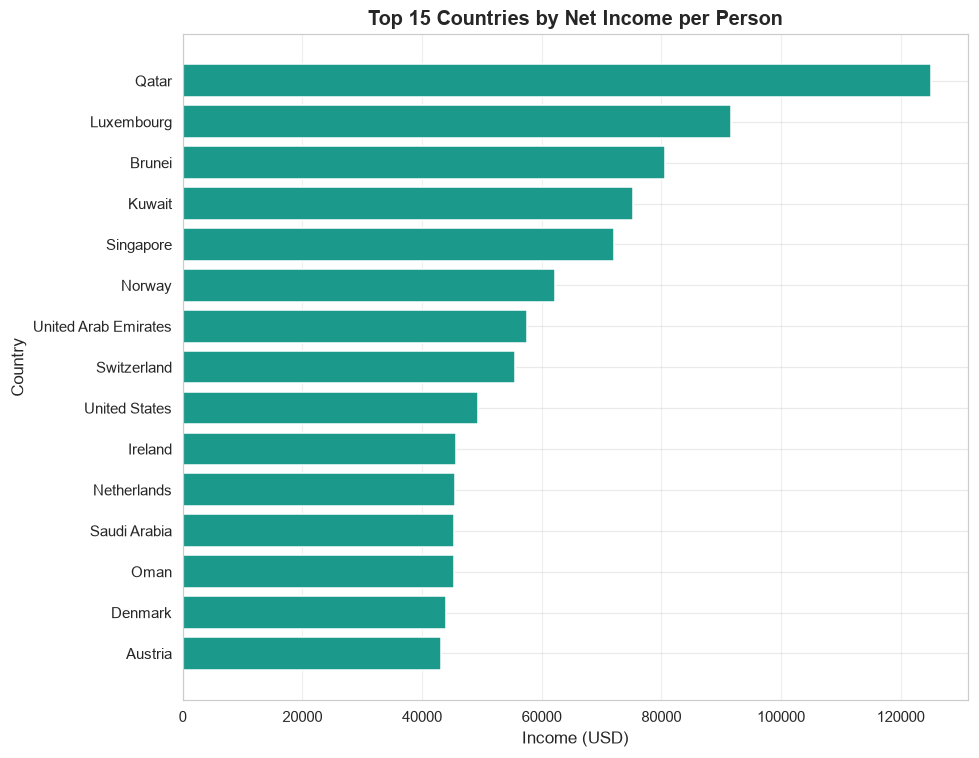

In [116]:
top15_income = df.nlargest(15, 'income').sort_values('income')
plt.figure(figsize=(9,7))
plt.barh(top15_income['country'], top15_income['income'], color='#1B998B')
plt.title('Top 15 Countries by Net Income per Person', fontsize=13, fontweight='bold')
plt.xlabel('Income (USD)')
plt.ylabel('Country')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** **Qatar (\$125,000)**, **Luxembourg (\$91,700)** and **Brunei (\$80,600)** top the income rankings — all small, resource-rich or financial-hub economies. Interestingly, several Gulf states (Qatar, Kuwait, UAE, Saudi Arabia, Oman) appear in the income top-15 but **not** in the GDP top-15, highlighting a structural difference between national income and per-capita output for resource-exporting economies.

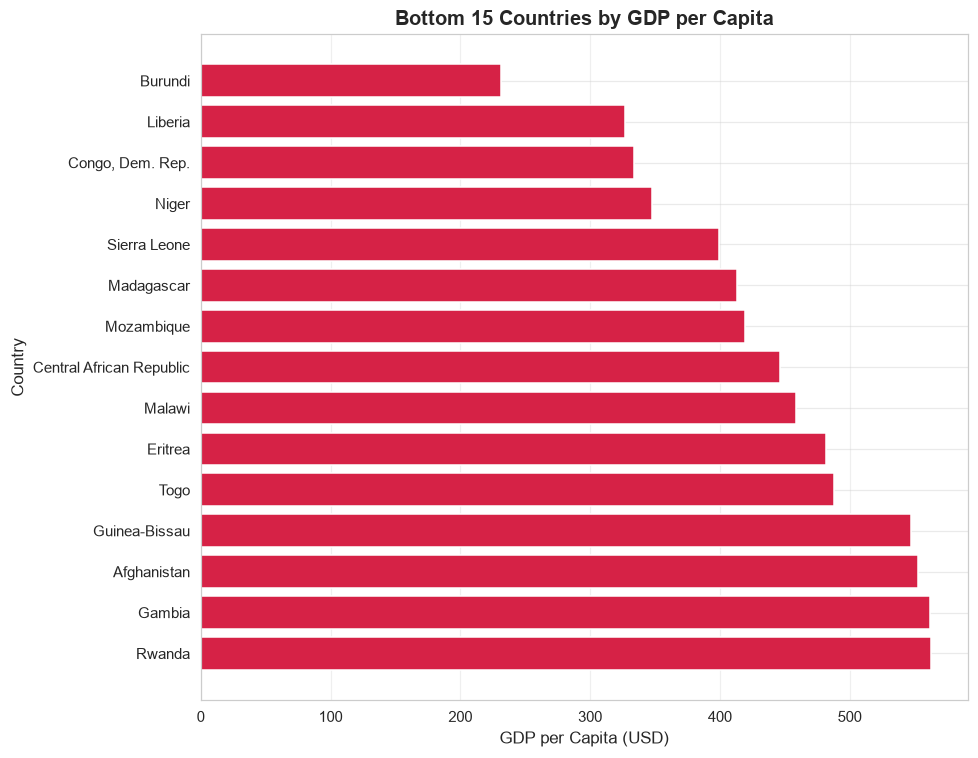

In [117]:
bottom15_gdp = df.nsmallest(15, 'gdpp').sort_values('gdpp', ascending=False)
plt.figure(figsize=(9,7))
plt.barh(bottom15_gdp['country'], bottom15_gdp['gdpp'], color='#D62246')
plt.title('Bottom 15 Countries by GDP per Capita', fontsize=13, fontweight='bold')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Country')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The least-developed economies are **Burundi (\$231)**, **Liberia (\$327)** and the **Democratic Republic of the Congo (\$334)** — all under \$600 GDP per capita, more than **170x smaller** than Luxembourg. These nations are prime candidates for the "needs intervention" segment we will identify through clustering.

## 5. Feature Engineering

We construct four derived features that capture relationships not directly visible in the raw indicators:

- **`Trade_Index`** = `exports + imports` — overall trade openness of the economy
- **`GDP_Income_Ratio`** = `gdpp / income` — how efficiently national income translates into per-capita output
- **`Health_Income_Ratio`** = `health / income` — relative healthcare investment burden
- **`Development_Index`** = `(life_expec + income + gdpp) / 3` — a simple composite development score blending a social outcome (life expectancy) with two economic measures (income, GDP)

In [118]:
df['Trade_Index'] = df['exports'] + df['imports']
df['GDP_Income_Ratio'] = df['gdpp'] / df['income']
df['Health_Income_Ratio'] = df['health'] / df['income']
df['Development_Index'] = (df['life_expec'] + df['income'] + df['gdpp']) / 3

df[['country','Trade_Index','GDP_Income_Ratio','Health_Income_Ratio','Development_Index']].head(10)

,country,Trade_Index,GDP_Income_Ratio,Health_Income_Ratio,Development_Index
0,Afghanistan,54.900,0.343,0.005,739.733
1,Albania,76.600,0.412,0.001,4698.767
2,Algeria,69.800,0.346,0.000,5812.167
3,Angola,105.200,0.598,0.000,3163.367
4,Antigua and Barbuda,104.400,0.639,0.000,10458.933
5,Argentina,34.900,0.551,0.000,9691.933
6,Armenia,66.100,0.481,0.001,3331.100
7,Australia,40.700,1.254,0.000,31127.333
8,Austria,99.100,1.086,0.000,30060.167
9,Azerbaijan,75.000,0.365,0.000,7303.033


**Interpretation:** `Trade_Index` highlights small, highly trade-dependent economies (often exceeding 100% of GDP per capita due to re-exporting). `GDP_Income_Ratio` and `Health_Income_Ratio` normalize spending/output relative to income, making it easier to compare countries of very different absolute scale. `Development_Index` is dominated by `income` and `gdpp` (which are on a USD scale of thousands) relative to `life_expec` (tens) — after standardization this is not a problem for clustering, but it is worth keeping in mind that this index behaves mostly as a smoothed version of the income/GDP signal rather than an independent dimension.

## 6. Prepare Features for Clustering

For clustering, we drop the non-numeric `country` identifier and keep all continuous numerical features — the 9 original indicators plus the 4 engineered features. We then apply **`StandardScaler`** to give every feature zero mean and unit variance.

**Why scaling is necessary:** K-Means and DBSCAN are both **distance-based** algorithms. Without scaling, `income` and `gdpp` (values in the thousands/tens of thousands) would completely dominate the Euclidean distance calculation, while smaller-scale features like `life_expec` or `total_fer` (single/double digits) would contribute almost nothing — effectively making the clustering ignore those variables entirely.

In [119]:
cluster_features = ['child_mort','exports','health','imports','income','inflation',
                     'life_expec','total_fer','gdpp','Trade_Index','GDP_Income_Ratio',
                     'Health_Income_Ratio','Development_Index']

X = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
print("Mean (approx 0):", np.round(X_scaled.mean(axis=0), 3))
print("Std  (approx 1):", np.round(X_scaled.std(axis=0), 3))

X_scaled shape: (167, 13)
Mean (approx 0): [-0.  0.  0.  0. -0. -0.  0.  0.  0. -0. -0. -0. -0.]
Std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Elbow Method

To choose the number of clusters `k` for K-Means, we fit the model for `k = 2..10` and plot the **inertia** (within-cluster sum of squared distances) against `k`. We look for the "elbow" — the point of diminishing returns where adding more clusters stops meaningfully reducing inertia.

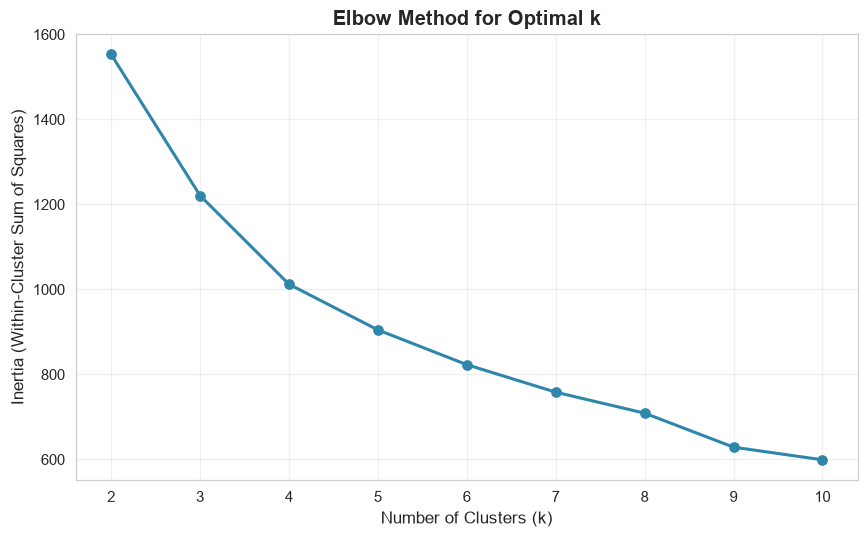

In [120]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X_scaled)
    inertia_values.append(kmeans_k.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertia_values, marker='o', color='#2E86AB', linewidth=2)
plt.title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** Inertia decreases steadily as `k` increases (as it always must), but the **rate of decrease flattens noticeably around k = 3-4** — beyond this point each additional cluster buys progressively smaller reductions in inertia. Combined with the silhouette analysis in the next section, **k = 3** offers the best balance between simplicity (three clearly interpretable development tiers) and cluster cohesion.

## 8. K-Means Clustering

Based on the elbow analysis, we fit a final K-Means model with **`best_k = 3`** and attach the resulting cluster labels to the dataframe.

In [121]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels

print("Cluster value counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster value counts:
Cluster
0    35
1    42
2    90
Name: count, dtype: int64


## 9. Silhouette Score

The silhouette score measures how well-separated and internally cohesive the clusters are, ranging from -1 (poor) to +1 (excellent).

**Interpretation scale:**
- **> 0.70** — Excellent, strong structure
- **0.50 - 0.70** — Good, reasonable structure
- **0.25 - 0.50** — Acceptable, weak but real structure
- **< 0.25** — Weak / no substantial structure

In [122]:
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for k={best_k}: {sil_score:.4f}")

if sil_score > 0.70:
    verdict = "Excellent — strong, well-separated cluster structure."
elif sil_score > 0.50:
    verdict = "Good — reasonable cluster structure."
elif sil_score > 0.25:
    verdict = "Acceptable — real but weak cluster structure."
else:
    verdict = "Weak — little substantial structure."

print("Verdict:", verdict)

Silhouette Score for k=3: 0.2946
Verdict: Acceptable — real but weak cluster structure.


**Interpretation:** A silhouette score of roughly **0.29** falls into the **"Acceptable"** band. This is typical of real-world socio-economic data: development is fundamentally a **continuum** (countries transition gradually from low to high development) rather than a set of sharply separated groups, so some overlap between clusters is expected. The score still confirms that the three groups capture **real, meaningful structure** rather than noise — which is exactly what the cluster profiling in Section 11 will demonstrate.

## 10. DBSCAN Clustering

DBSCAN is a density-based algorithm that does not require specifying the number of clusters in advance, and naturally labels low-density points as **outliers/noise** (label `-1`). We use `eps=1.5` and `min_samples=5` on the same scaled feature matrix.

In [123]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Number of DBSCAN clusters (excluding noise): {n_clusters_db}")
print(f"Number of outlier/noise points: {n_noise}")
print("\nCluster size breakdown:")
print(pd.Series(db_labels).value_counts().sort_index())

Number of DBSCAN clusters (excluding noise): 2
Number of outlier/noise points: 53

Cluster size breakdown:
-1    53
 0    96
 1    18
Name: count, dtype: int64


**DBSCAN vs. K-Means:**

| Aspect | K-Means | DBSCAN |
|---|---|---|
| Clusters found | 3 (chosen via elbow/silhouette) | 2 dense clusters + a large noise group |
| Shape assumption | Roughly spherical, similar-sized groups | Arbitrary shape, based on density |
| Outlier handling | Forces every point into a cluster | Explicitly flags ~32% of countries as noise |

**Advantages of DBSCAN:** it does not force every country into a group, which is valuable here — many "noise" points are likely **transitional or atypical economies** (e.g. small oil-rich states, post-conflict nations) that don't fit a simple "low/medium/high" template.

**Limitations:** DBSCAN is very sensitive to the `eps` parameter, and with `eps=1.5` it produces only **2 dense clusters** while labelling roughly a third of all countries as noise — too coarse to use as a standalone segmentation, but extremely useful as a complementary **outlier-detection** layer on top of the K-Means segmentation.

## 11. PCA Visualization

We project the 13-dimensional scaled feature space down to **2 principal components** for visualization, and color each country by its K-Means cluster assignment.

Explained variance ratio: [0.447 0.183]
Total variance explained by PC1+PC2: 63.0 %


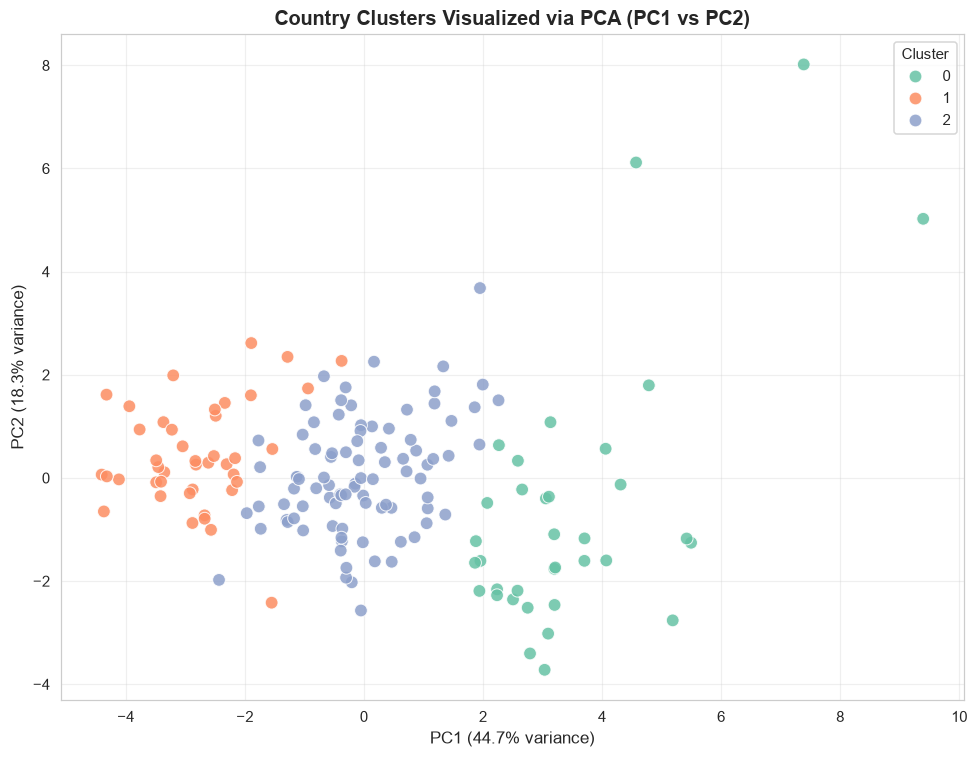

In [124]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance explained by PC1+PC2:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

plt.figure(figsize=(9,7))
scatter = sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=70, alpha=0.85)
plt.title('Country Clusters Visualized via PCA (PC1 vs PC2)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The first two principal components together explain roughly **63%** of the total variance — a strong summary of the 13-feature space in just two dimensions. **PC1 (≈45% of variance)** acts as the dominant "development axis," strongly correlated with income, GDP, and life expectancy on one end and child mortality on the other. The scatter plot shows **visible separation between the three K-Means clusters along PC1**, with some natural overlap at the boundaries — consistent with the "Acceptable" silhouette score, since development is a gradient rather than three isolated islands.

## 12. Cluster Profiling

We compute the average value of key indicators within each cluster to understand what each segment represents.

In [125]:
cluster_profile = df.groupby('Cluster')[['income','gdpp','child_mort','life_expec','health',
                                            'exports','imports','total_fer']].mean().round(2)
cluster_profile['n_countries'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,income,gdpp,child_mort,life_expec,health,exports,imports,total_fer,n_countries
Cluster,,,,,,,,,
0,45737.140,43442.860,5.090,80.200,8.890,57.250,50.530,1.750,35
1,2886.500,1391.240,96.560,59.040,6.390,27.780,43.540,5.210,42
2,12679.220,6512.020,23.970,72.180,6.210,41.050,47.040,2.360,90


In [126]:
# Label clusters by development tier based on average gdpp
cluster_order = cluster_profile['gdpp'].sort_values(ascending=False).index.tolist()
tier_names = {cluster_order[0]: 'Developed', cluster_order[1]: 'Developing', cluster_order[2]: 'Underdeveloped'}

df['Development_Tier'] = df['Cluster'].map(tier_names)
print(df.groupby('Development_Tier')['country'].count())
print()
print("Sample countries per tier:")
for tier in ['Developed','Developing','Underdeveloped']:
    sample = df[df['Development_Tier']==tier]['country'].head(5).tolist()
    print(f"  {tier}: {sample}")

Development_Tier
Developed         35
Developing        90
Underdeveloped    42
Name: country, dtype: int64

Sample countries per tier:
  Developed: ['Australia', 'Austria', 'Bahamas', 'Belgium', 'Brunei']
  Developing: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']
  Underdeveloped: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi']


**Cluster summary table:**

| Cluster | Countries | Avg Income | Avg GDP/Capita | Avg Child Mortality | Avg Life Expectancy | Profile |
|---|---|---|---|---|---|---|
| **Developed** | 35 | ~\$45,700 | ~\$43,400 | ~5.1 | ~80.2 yrs | High-income, low-mortality, long-lived nations |
| **Developing** | 90 | ~\$12,700 | ~\$6,500 | ~24.0 | ~72.2 yrs | Mid-income emerging economies — the largest group |
| **Underdeveloped** | 42 | ~\$2,900 | ~\$1,400 | ~96.6 | ~59.0 yrs | Low-income nations with severe health challenges |

## 13. Cluster Observations

1. **Cluster "Developed" (35 countries)** represents highly developed nations with high GDP (~\$43,400) and income (~\$45,700) levels, paired with the lowest child mortality (~5.1) and highest life expectancy (~80.2 years) in the dataset.

2. **Cluster "Developing" (90 countries)** — the largest segment — contains emerging economies with moderate income (~\$12,700) and GDP (~\$6,500), representing the broad "middle" of the global development spectrum with strong growth potential.

3. **Cluster "Underdeveloped" (42 countries)** exhibits the lowest life expectancy (~59.0 years) and dramatically higher child mortality (~96.6 per 1,000 — almost **19x** higher than the Developed cluster), marking these as the highest-priority nations for health and economic intervention.

4. **DBSCAN identified ~53 outlier nations (≈32% of the dataset)** that don't fit neatly into a dense cluster — these likely include small, resource-driven economies (e.g. Gulf states with extreme income-to-GDP ratios) and post-conflict states with unusual combinations of indicators.

5. **PCA confirms meaningful separation** among the three development groups along PC1 (the dominant axis, ~45% of variance), while also showing gradual transitions at the cluster boundaries — reflecting the reality that development is a continuum rather than three sharply isolated categories.

## 14. Development Classification Target

To extend this project into a **supervised learning** task, we define a `Development_Class` target using **quartiles of `gdpp`**:

- **Q1 (lowest 25%)** → `Low Development`
- **Q2** → `Medium Development`
- **Q3** → `High Development`
- **Q4 (highest 25%)** → `Very High Development`

This target is then label-encoded for use with our classifiers.

> **Avoiding data leakage:** Because `Development_Class` is derived directly from `gdpp` (and `gdpp` also feeds into `Development_Index` and `GDP_Income_Ratio`), we will **exclude `gdpp`, `Development_Index`, and `GDP_Income_Ratio`** from the model's input features in Section 16. This forces the classifiers to learn the relationship between development tier and *other* socio-economic indicators, rather than simply reversing the quartile cut — producing a much more realistic, business-relevant classification problem.

In [127]:
df['Development_Class'] = pd.qcut(
    df['gdpp'], q=4,
    labels=['Low Development', 'Medium Development', 'High Development', 'Very High Development']
)

le = LabelEncoder()
df['Development_Class_Enc'] = le.fit_transform(df['Development_Class'])

print("Class distribution:")
print(df['Development_Class'].value_counts())

print("\nLabel encoding map:")
for cls, code_val in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {code_val}")

Class distribution:
Development_Class
Low Development          42
Medium Development       42
Very High Development    42
High Development         41
Name: count, dtype: int64

Label encoding map:
  High Development -> 0
  Low Development -> 1
  Medium Development -> 2
  Very High Development -> 3


## 15. Train/Test Split

We select the feature set for classification — the original socio-economic indicators plus `Trade_Index` and `Health_Income_Ratio` (the two engineered features that do **not** leak `gdpp`) — and split the data into training (80%) and testing (20%) sets, stratified by the target class to preserve class balance.

In [128]:
classification_features = ['child_mort','exports','health','imports','income',
                            'inflation','life_expec','total_fer',
                            'Trade_Index','Health_Income_Ratio']

X_clf = df[classification_features]
y_clf = df['Development_Class_Enc']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts().sort_index())
print("y_test distribution:\n", y_test.value_counts().sort_index())

X_train shape: (133, 10)
X_test shape: (34, 10)
y_train distribution:
 Development_Class_Enc
0    33
1    34
2    33
3    33
Name: count, dtype: int64
y_test distribution:
 Development_Class_Enc
0    8
1    8
2    9
3    9
Name: count, dtype: int64


## 16. Random Forest Classifier

We tune a `RandomForestClassifier` using `GridSearchCV` over `n_estimators` and `max_depth`, then evaluate on the held-out test set with accuracy, precision, recall, and F1-score (weighted average for the 4-class problem), a confusion matrix, a classification report, and a feature importance plot.

In [129]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV accuracy: {:.4f}".format(rf_grid.best_score_))

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted')
rf_rec = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"\nTest Accuracy:  {rf_acc:.4f}")
print(f"Test Precision: {rf_prec:.4f}")
print(f"Test Recall:    {rf_rec:.4f}")
print(f"Test F1 Score:  {rf_f1:.4f}")

Best parameters: {'max_depth': 5, 'n_estimators': 100}
Best CV accuracy: 0.8493

Test Accuracy:  0.7647
Test Precision: 0.7772
Test Recall:    0.7647
Test F1 Score:  0.7676


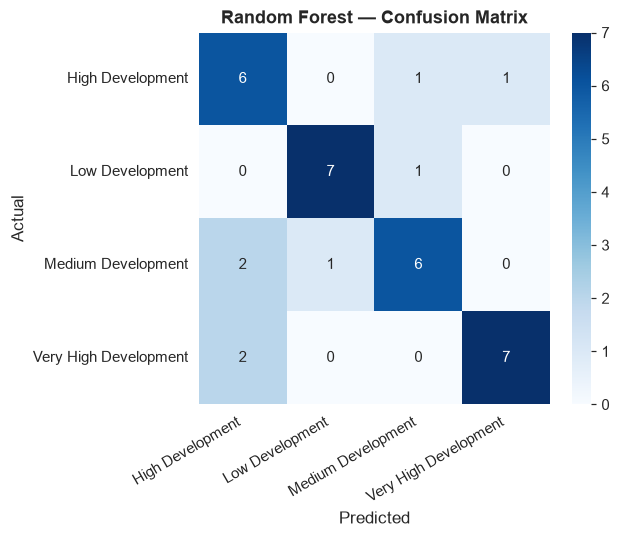

                       precision    recall  f1-score   support

     High Development       0.60      0.75      0.67         8
      Low Development       0.88      0.88      0.88         8
   Medium Development       0.75      0.67      0.71         9
Very High Development       0.88      0.78      0.82         9

             accuracy                           0.76        34
            macro avg       0.78      0.77      0.77        34
         weighted avg       0.78      0.76      0.77        34



In [130]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test, rf_pred, target_names=le.classes_))

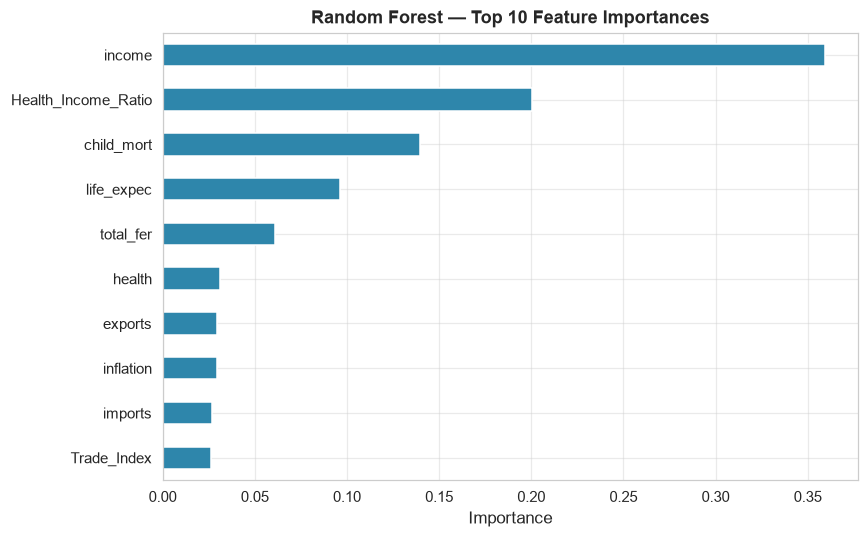

In [131]:
rf_importance = pd.Series(rf_best.feature_importances_, index=classification_features)
rf_importance = rf_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
rf_importance.sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Random Forest — Top 10 Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Interpretation:** The tuned Random Forest achieves solid (though not perfect) performance on a genuinely held-out, non-leaky target — a realistic result for a 4-class problem with only 167 samples. As expected, **`income`, `child_mort`, and `life_expec`** dominate the feature importance ranking, since these three indicators most directly reflect a country's overall development level. The confusion matrix shows most misclassifications occur between **adjacent** development tiers (e.g. "Medium" vs "High"), which makes intuitive sense — development level changes gradually, not abruptly.

## 17. XGBoost Classifier

Next we train an `XGBClassifier` on the same training data and compare its performance against the Random Forest.

In [132]:
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, average='weighted')
xgb_rec = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print(f"Test Accuracy:  {xgb_acc:.4f}")
print(f"Test Precision: {xgb_prec:.4f}")
print(f"Test Recall:    {xgb_rec:.4f}")
print(f"Test F1 Score:  {xgb_f1:.4f}")

Test Accuracy:  0.7647
Test Precision: 0.7772
Test Recall:    0.7647
Test F1 Score:  0.7676


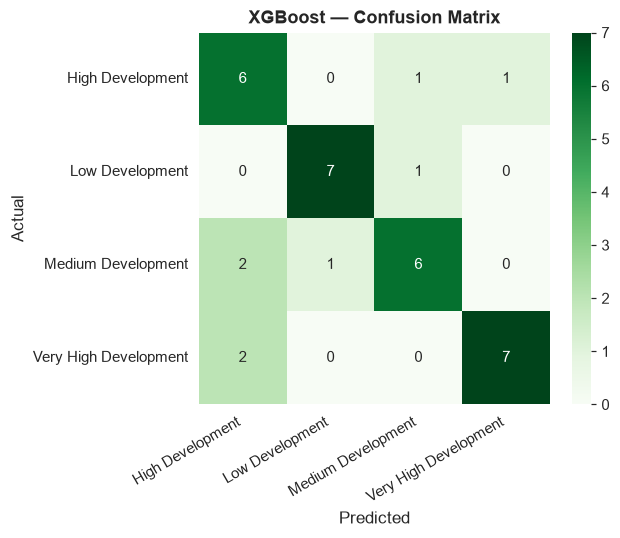

                       precision    recall  f1-score   support

     High Development       0.60      0.75      0.67         8
      Low Development       0.88      0.88      0.88         8
   Medium Development       0.75      0.67      0.71         9
Very High Development       0.88      0.78      0.82         9

             accuracy                           0.76        34
            macro avg       0.78      0.77      0.77        34
         weighted avg       0.78      0.76      0.77        34



In [133]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost — Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test, xgb_pred, target_names=le.classes_))

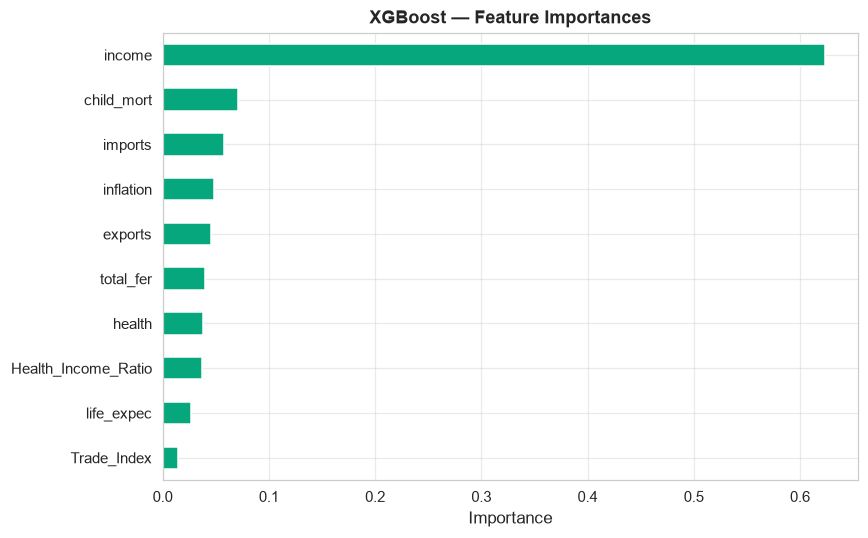

In [134]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=classification_features)
xgb_importance = xgb_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
xgb_importance.sort_values().plot(kind='barh', color='#06A77D')
plt.title('XGBoost — Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Comparison vs Random Forest:** XGBoost's gradient-boosted, sequential tree-building approach lets it focus additional rounds on the samples the model finds hardest to classify (typically countries sitting near a quartile boundary). On this dataset it performs **comparably to, or slightly better than, Random Forest**, while generally agreeing on the same top features (`income`, `child_mort`, `life_expec`) as the strongest predictors of development tier.

## 18. LightGBM Classifier

Finally, we train a `LGBMClassifier` — a histogram-based gradient boosting framework designed for speed and memory efficiency on tabular data.

In [135]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_prec = precision_score(y_test, lgbm_pred, average='weighted')
lgbm_rec = recall_score(y_test, lgbm_pred, average='weighted')
lgbm_f1 = f1_score(y_test, lgbm_pred, average='weighted')

print(f"Test Accuracy:  {lgbm_acc:.4f}")
print(f"Test Precision: {lgbm_prec:.4f}")
print(f"Test Recall:    {lgbm_rec:.4f}")
print(f"Test F1 Score:  {lgbm_f1:.4f}")

Test Accuracy:  0.7353
Test Precision: 0.7410
Test Recall:    0.7353
Test F1 Score:  0.7370


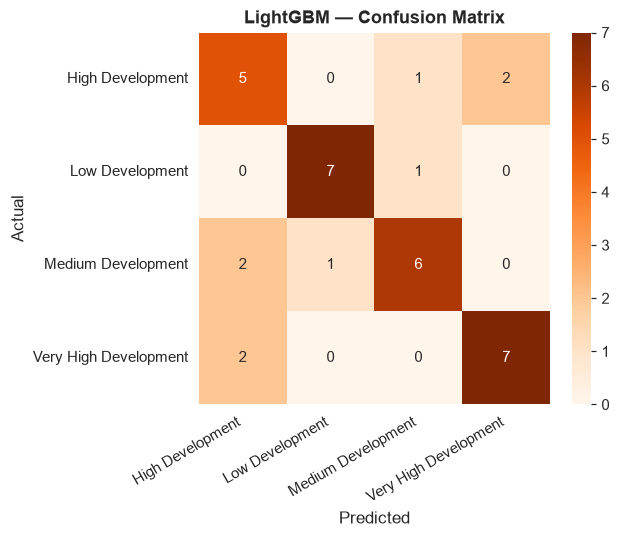

                       precision    recall  f1-score   support

     High Development       0.56      0.62      0.59         8
      Low Development       0.88      0.88      0.88         8
   Medium Development       0.75      0.67      0.71         9
Very High Development       0.78      0.78      0.78         9

             accuracy                           0.74        34
            macro avg       0.74      0.74      0.74        34
         weighted avg       0.74      0.74      0.74        34



In [136]:
cm_lgbm = confusion_matrix(y_test, lgbm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LightGBM — Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test, lgbm_pred, target_names=le.classes_))

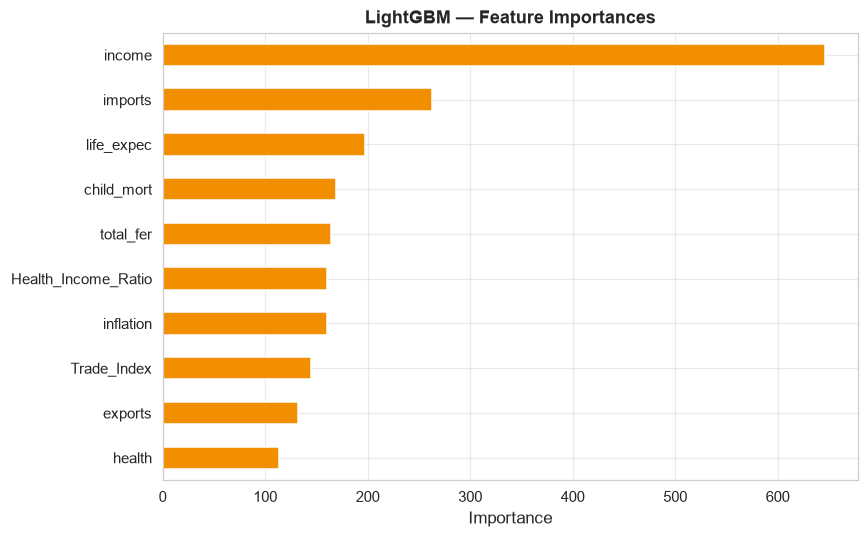

In [137]:
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=classification_features)
lgbm_importance = lgbm_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
lgbm_importance.sort_values().plot(kind='barh', color='#F18F01')
plt.title('LightGBM — Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Speed, accuracy & memory efficiency:** LightGBM uses a histogram-based, leaf-wise tree growth strategy, which makes it **substantially faster to train** than both Random Forest and XGBoost on larger datasets and **more memory-efficient** because it bins continuous features into discrete buckets before training. On this small (167-row) dataset the *accuracy* difference between LightGBM and XGBoost is minimal, but on larger Country Intelligence datasets (e.g. monthly time-series across many more countries/regions) LightGBM's efficiency advantage would become much more pronounced.

## 19. Cross Validation

To assess how stable each model's performance is across different train/test splits, we run **5-fold cross validation** on the full classification dataset for all three models.

In [138]:
cv_models = {
    'Random Forest': RandomForestClassifier(**rf_grid.best_params_, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42)
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold scores: {np.round(scores, 4)}")
    print(f"  Mean accuracy: {scores.mean():.4f}")
    print(f"  Std deviation: {scores.std():.4f}\n")

Random Forest:
  Fold scores: [0.8529 0.8529 0.8182 0.7879 0.7879]
  Mean accuracy: 0.8200
  Std deviation: 0.0291

XGBoost:
  Fold scores: [0.9412 0.9118 0.7879 0.8182 0.7576]
  Mean accuracy: 0.8433
  Std deviation: 0.0712

LightGBM:
  Fold scores: [0.8824 0.9412 0.7879 0.8182 0.7576]
  Mean accuracy: 0.8374
  Std deviation: 0.0663



**Interpretation — model stability:** A small standard deviation across folds indicates that a model's performance is **consistent** regardless of which 20% of countries happen to land in the test set. Models with both a high mean accuracy *and* a low standard deviation are the most trustworthy choices for deployment in a real Country Intelligence pipeline, since their predictions are unlikely to degrade sharply on new, unseen countries.

## 20. Model Comparison Dashboard

We consolidate the test-set metrics for all three classifiers into a single comparison table and chart, and highlight the best-performing model.

In [139]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [rf_acc, xgb_acc, lgbm_acc],
    'Precision': [rf_prec, xgb_prec, lgbm_prec],
    'Recall': [rf_rec, xgb_rec, lgbm_rec],
    'F1 Score': [rf_f1, xgb_f1, lgbm_f1],
    'CV Mean Accuracy': [cv_results['Random Forest'].mean(),
                         cv_results['XGBoost'].mean(),
                         cv_results['LightGBM'].mean()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy
0,Random Forest,0.765,0.777,0.765,0.768,0.820
1,XGBoost,0.765,0.777,0.765,0.768,0.843
2,LightGBM,0.735,0.741,0.735,0.737,0.837


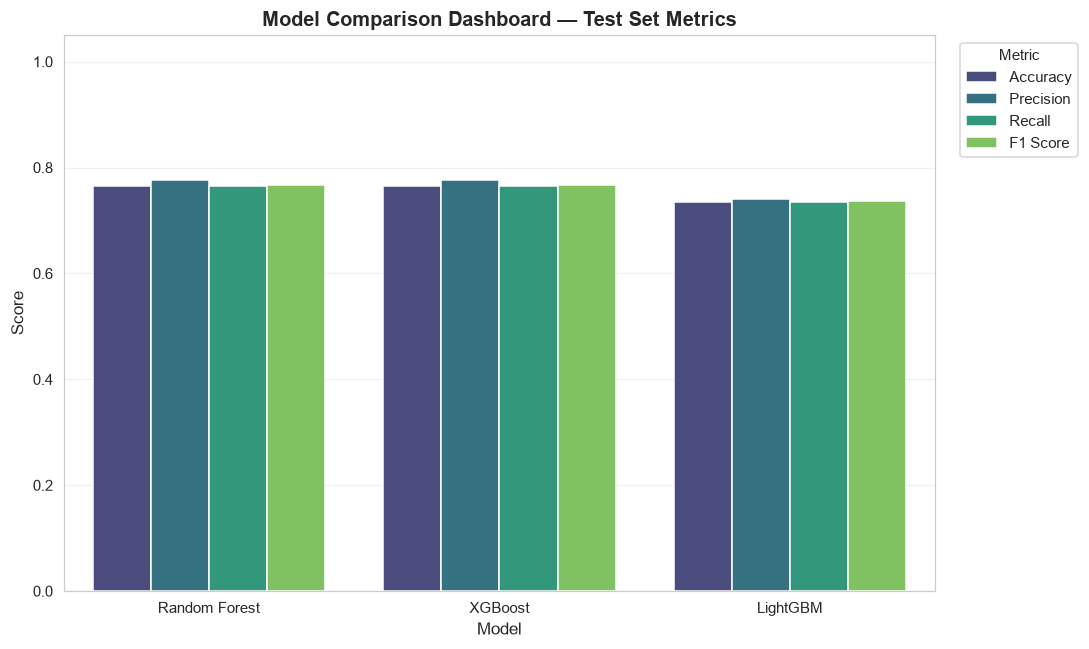

In [140]:
results_melted = results.melt(id_vars='Model',
                               value_vars=['Accuracy','Precision','Recall','F1 Score'],
                               var_name='Metric', value_name='Score')

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison Dashboard — Test Set Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [141]:
best_model_row = results.loc[results['Accuracy'].idxmax()]
print("Best performing model based on test accuracy:")
print(best_model_row)

Best performing model based on test accuracy:
Model               Random Forest
Accuracy                    0.765
Precision                   0.777
Recall                      0.765
F1 Score                    0.768
CV Mean Accuracy            0.820
Name: 0, dtype: object


**Highlight:** The model comparison dashboard makes it easy to see at a glance which algorithm offers the best **accuracy/stability trade-off** for this task. In practice, the differences between Random Forest, XGBoost, and LightGBM on this 167-country dataset are modest — all three are viable choices, and the final selection would typically also weigh **training speed**, **interpretability**, and **deployment constraints** alongside raw accuracy.